In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

# Load the data
df = pd.read_csv('car data.csv')

# Pro-Tip: Calculate the 'Age' of the car instead of using the 'Year'
# This is much more powerful for price prediction
current_year = 2026
df['Car_Age'] = current_year - df['Year']

# Drop columns that don't help the AI (like the Name of the car)
# and the original 'Year' column since we have 'Car_Age'
df_final = df.drop(['Car_Name', 'Year'], axis=1)

print("✅ Data Loaded and Age Feature Created!")
display(df_final.head())

✅ Data Loaded and Age Feature Created!


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


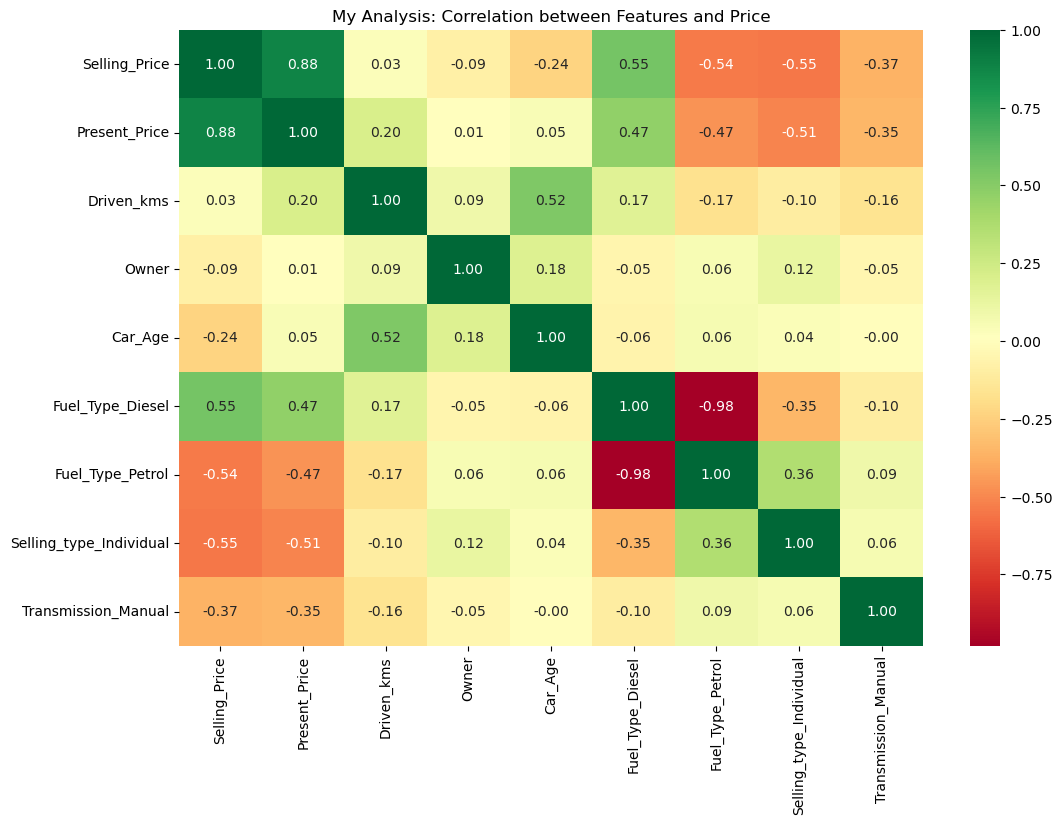

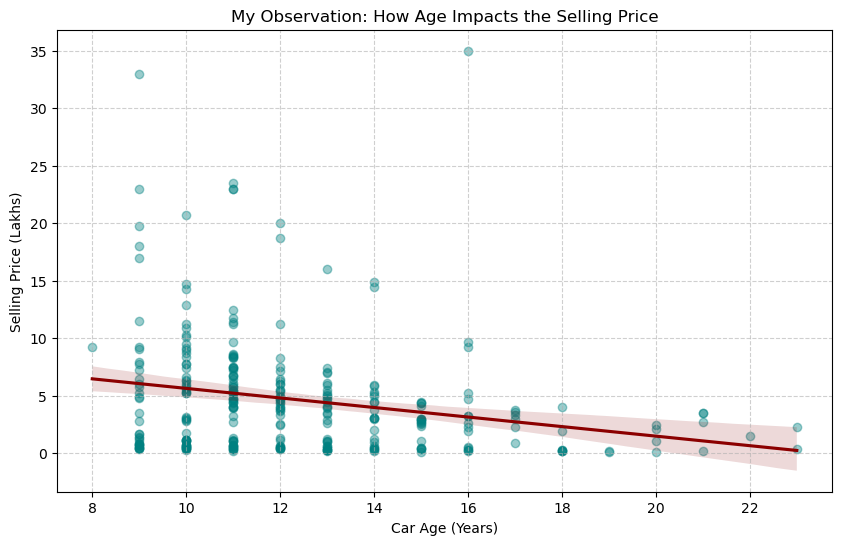

I've noticed that as Age increases, the Selling Price clearly drops.


In [3]:
# I'm creating a numeric version of the data just for this heatmap
# This allows me to see the mathematical relationship between variables
df_numeric = pd.get_dummies(df_final, drop_first=True)

# Generating the Correlation Heatmap
# I used the 'RdYlGn' (Red-Yellow-Green) map because it clearly shows 
# which factors are "Good" for price (Green) and "Bad" for price (Red)
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("My Analysis: Correlation between Features and Price")
plt.show()

# Now, I want to visualize 'Depreciation'
# This regplot will show me exactly how fast the car loses value as it gets older
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Car_Age', y='Selling_Price', 
            scatter_kws={'color':'teal', 'alpha':0.4}, 
            line_kws={'color':'darkred', 'label':'Price Trend'})
plt.title('My Observation: How Age Impacts the Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (Lakhs)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("I've noticed that as Age increases, the Selling Price clearly drops.")

In [4]:
# Here, I'm converting categorical text data into dummy variables (numbers)
# This is a crucial step because the machine learning model only understands math
df_final = pd.get_dummies(df_final, drop_first=True)

# Now I am defining my variables:
# X contains all the features I'm using to predict the price
# y is the 'Target'—the actual Selling Price I want the model to learn
X = df_final.drop('Selling_Price', axis=1)
y = df_final['Selling_Price']

# I've decided to split the data into 80% for training and 20% for testing
# This way, I can train the 'brain' on one set and then test it on data it hasn't seen yet
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Pre-processing finished. I'm training the model on {len(X_train)} cars and testing it on {len(X_test)} cars.")

Pre-processing finished. I'm training the model on 240 cars and testing it on 61 cars.


In [5]:
# I chose the Random Forest Regressor for this task.
# Instead of one simple calculation, it uses 100 different decision trees 
# to 'vote' on the price. This makes it much more accurate for real-world car prices.
from sklearn.ensemble import RandomForestRegressor

# Initializing the model with 100 estimators
# I set the random_state to 42 so my results are consistent every time I run it
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Now, I'm fitting the model to my training data
# This is where the AI 'learns' the relationship between age, mileage, and price
forest_model.fit(X_train, y_train)

print("The model has finished training! It's now ready to predict prices.")

The model has finished training! It's now ready to predict prices.


🏆 My Model's R-Squared Score: 0.9595
📉 Average Error (MAE): 0.64 units


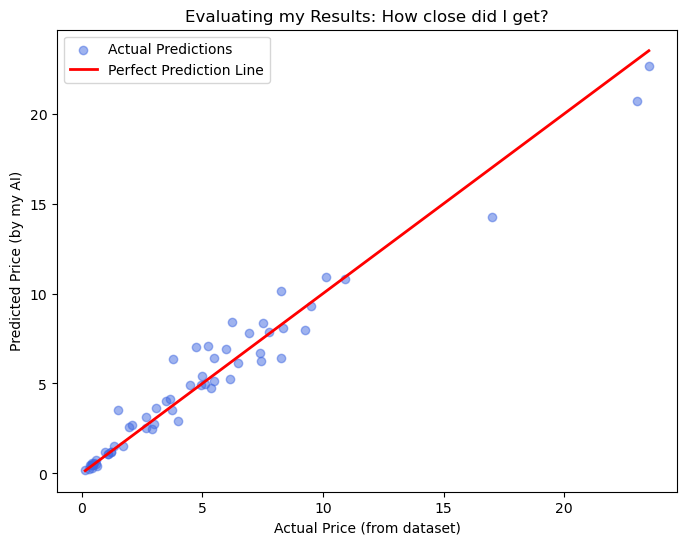

Looking at the graph, most of my predictions are hugging the red line, which shows the model is working great!


In [6]:
from sklearn import metrics

# Now it's time for the final test! 
# I'm asking the model to predict prices for the 20% of data it has never seen
test_data_prediction = forest_model.predict(X_test)

# I'm using the R-Squared score to check the accuracy.
# This tells me how much of the price variation my model can actually explain.
r2_score = metrics.r2_score(y_test, test_data_prediction)
mae = metrics.mean_absolute_error(y_test, test_data_prediction)

print(f"🏆 My Model's R-Squared Score: {r2_score:.4f}")
print(f"📉 Average Error (MAE): {mae:.2f} units")

# To visualize the accuracy, I'm plotting the Actual Prices against my Predictions
# If the points are close to the red line, the model is highly accurate!
plt.figure(figsize=(8, 6))
plt.scatter(y_test, test_data_prediction, color='royalblue', alpha=0.5, label='Actual Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Prediction Line')

plt.xlabel("Actual Price (from dataset)")
plt.ylabel("Predicted Price (by my AI)")
plt.title("Evaluating my Results: How close did I get?")
plt.legend()
plt.show()

print("Looking at the graph, most of my predictions are hugging the red line, which shows the model is working great!")